# Stage 1 PD Model (Production-Quality, Leakage-Safe)

This notebook builds a Probability of Default model at loan origination with strict leakage controls, out-of-time validation, cross-validation, and calibration comparison.

Sections:
1. Data Cleaning
2. Feature Audit
3. Splitting
4. Preprocessing
5. Modeling
6. Calibration
7. Evaluation
8. Interpretation

In [30]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
 )
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)

DATA_PATH = Path("../data/accepted_loans.csv")
RANDOM_STATE = 42
MAX_TRAIN_ROWS = 300_000

print(f"Dataset: {DATA_PATH.resolve()}")

Dataset: C:\Users\Ashvik\projects\CLARE\data\accepted_loans.csv


## 1) Data Cleaning
Use strict binary target labels and keep only mature outcomes.

In [31]:
df_raw = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Raw shape: {df_raw.shape}")

status_col = "loan_status"
label_map = {"Fully Paid": 0, "Charged Off": 1}

if status_col not in df_raw.columns:
    raise KeyError("Missing required target source column: loan_status")

df_raw[status_col] = df_raw[status_col].astype("string").str.strip()
df = df_raw[df_raw[status_col].isin(label_map.keys())].copy()
df["default_flag"] = df[status_col].map(label_map).astype("int8")

print("\nClass distribution after strict filtering:")
print(df[status_col].value_counts(dropna=False))
print("\nDefault rate:")
print(df["default_flag"].value_counts(normalize=True).rename("proportion"))

date_col_candidates = ["issue_d", "issue_date", "issue_dt", "funded_amnt_date"]
issue_col = next((c for c in date_col_candidates if c in df.columns), None)

if issue_col is None:
    raise ValueError("No issue date column found. Time-aware split is required for this workflow.")

issue_parsed = pd.to_datetime(df[issue_col], errors="coerce")
if issue_parsed.isna().all() and issue_col == "issue_d":
    issue_parsed = pd.to_datetime(df[issue_col], format="%b-%Y", errors="coerce")

df["issue_date_parsed"] = issue_parsed
df = df[df["issue_date_parsed"].notna()].copy()

# Optional maturation filter to reduce right-censoring.
max_issue = df["issue_date_parsed"].max()
maturity_cutoff = max_issue - pd.DateOffset(months=36)
rows_before = len(df)
df = df[df["issue_date_parsed"] <= maturity_cutoff].copy()
rows_after = len(df)

df["issue_year"] = df["issue_date_parsed"].dt.year.astype("int16")
df["issue_month"] = df["issue_date_parsed"].dt.month.astype("int8")

print(f"\nApplied 36-month maturity filter: {rows_before:,} -> {rows_after:,}")
print(f"Issue date range retained: {df['issue_date_parsed'].min()} to {df['issue_date_parsed'].max()}")

Raw shape: (2260701, 151)

Class distribution after strict filtering:
loan_status
Fully Paid     1076751
Charged Off     268559
Name: count, dtype: Int64

Default rate:
default_flag
0    0.800374
1    0.199626
Name: proportion, dtype: float64

Applied 36-month maturity filter: 1,345,310 -> 826,604
Issue date range retained: 2007-06-01 00:00:00 to 2015-12-01 00:00:00


## 2) Feature Audit
Create a feature availability audit and enforce strict origination-time feature policy.

In [32]:
target_col = "default_flag"

explicit_drop_cols = {
    # Post-origination payment/performance fields
    "total_pymnt", "total_pymnt_inv", "total_rec_prncp", "total_rec_int", "total_rec_late_fee",
    "recoveries", "collection_recovery_fee", "out_prncp", "out_prncp_inv",
    "last_pymnt_d", "last_pymnt_amnt", "next_pymnt_d", "last_credit_pull_d",
    "last_fico_range_high", "last_fico_range_low",
    # Approval / post-decision amounts not available at true origination decision
    "funded_amnt", "funded_amnt_inv", "installment",
    # IDs / metadata
    "id", "member_id", "url", "desc", "title",
}

token_drop_list = ["settlement", "recovery", "collection", "last_pymnt", "next_pymnt", "hardship"]
raw_date_drop_cols = {"issue_date_parsed", "issue_d", "issue_date", "issue_dt", "funded_amnt_date"}

audit_rows = []
for col in df.columns:
    if col == target_col:
        continue

    col_lower = col.lower()
    available = True
    kept = True
    reason = "Available at origination"

    if col == status_col:
        available = False
        kept = False
        reason = "Target-source column; never a model input"
    elif col in explicit_drop_cols:
        available = False
        kept = False
        reason = "Post-origination or non-origination field"
    elif any(tok in col_lower for tok in token_drop_list):
        available = False
        kept = False
        reason = "Leakage token match"
    elif col in raw_date_drop_cols:
        available = True
        kept = False
        reason = "Use only derived date features (issue_year, issue_month)"
    elif col in {"issue_year", "issue_month"}:
        available = True
        kept = True
        reason = "Derived origination timing feature"

    audit_rows.append(
        {
            "Feature": col,
            "Available at Origination?": "Yes" if available else "No",
            "Kept?": "Yes" if kept else "No",
            "Reason": reason,
        }
    )

audit_df = pd.DataFrame(audit_rows).sort_values(["Kept?", "Feature"], ascending=[False, True]).reset_index(drop=True)
kept_features = audit_df.loc[audit_df["Kept?"] == "Yes", "Feature"].tolist()

print(f"Total candidate features audited: {len(audit_df)}")
print(f"Features kept for modeling: {len(kept_features)}")
display(audit_df.head(40))

Total candidate features audited: 154
Features kept for modeling: 107


,Feature,Available at Origination?,Kept?,Reason
0,acc_now_delinq,Yes,Yes,Available at origination
1,acc_open_past_24mths,Yes,Yes,Available at origination
2,addr_state,Yes,Yes,Available at origination
3,all_util,Yes,Yes,Available at origination
4,annual_inc,Yes,Yes,Available at origination
5,annual_inc_joint,Yes,Yes,Available at origination
6,application_type,Yes,Yes,Available at origination
7,avg_cur_bal,Yes,Yes,Available at origination
8,bc_open_to_buy,Yes,Yes,Available at origination
9,bc_util,Yes,Yes,Available at origination


## 3) Splitting
Use strict out-of-time split (first 80% train, last 20% test).

In [33]:
split_df = df[kept_features + [target_col, "issue_date_parsed"]].copy()
split_df = split_df.sort_values("issue_date_parsed").reset_index(drop=True)

# Find a cutoff near 80% that preserves both classes in both splits.
candidate_fracs = [0.80, 0.79, 0.81, 0.78, 0.82, 0.77, 0.83]
cutoff_idx = None

for frac in candidate_fracs:
    idx = int(len(split_df) * frac)
    if idx <= 0 or idx >= len(split_df):
        continue
    y_left = split_df.iloc[:idx][target_col]
    y_right = split_df.iloc[idx:][target_col]
    if y_left.nunique() == 2 and y_right.nunique() == 2:
        cutoff_idx = idx
        break

if cutoff_idx is None:
    raise ValueError("Could not find a valid out-of-time split with both classes in train and test.")

train_df = split_df.iloc[:cutoff_idx].copy()
test_df = split_df.iloc[cutoff_idx:].copy()

X_train_full = train_df.drop(columns=[target_col, "issue_date_parsed"], errors="ignore")
y_train_full = train_df[target_col].copy()
X_test = test_df.drop(columns=[target_col, "issue_date_parsed"], errors="ignore")
y_test = test_df[target_col].copy()

print(f"Split method: out_of_time")
print(f"Train shape (pre-sampling): {X_train_full.shape}")
print(f"Test shape: {X_test.shape}")
print(f"Train default rate: {y_train_full.mean():.4f}")
print(f"Test default rate: {y_test.mean():.4f}")
print(f"Train date range: {train_df['issue_date_parsed'].min()} -> {train_df['issue_date_parsed'].max()}")
print(f"Test date range:  {test_df['issue_date_parsed'].min()} -> {test_df['issue_date_parsed'].max()}")

Split method: out_of_time
Train shape (pre-sampling): (661283, 107)
Test shape: (165321, 107)
Train default rate: 0.1803
Test default rate: 0.2002
Train date range: 2007-06-01 00:00:00 -> 2015-08-01 00:00:00
Test date range:  2015-08-01 00:00:00 -> 2015-12-01 00:00:00


## 4) Sampling
Apply row cap only on the training split, preserving class balance.

In [34]:
if len(X_train_full) > MAX_TRAIN_ROWS:
    X_train, _, y_train, _ = train_test_split(
        X_train_full,
        y_train_full,
        train_size=MAX_TRAIN_ROWS,
        stratify=y_train_full,
        random_state=RANDOM_STATE,
    )
    print(f"Applied training cap: {len(X_train_full):,} -> {len(X_train):,}")
else:
    X_train, y_train = X_train_full.copy(), y_train_full.copy()
    print(f"Training cap not needed: {len(X_train):,} rows")

print(f"Sampled train default rate: {y_train.mean():.4f}")

Applied training cap: 661,283 -> 300,000
Sampled train default rate: 0.1803


## 5) Preprocessing
Use separate preprocessing pipelines for Logistic Regression and XGBoost.

In [35]:
numeric_features = X_train.select_dtypes(include=[np.number, "bool"]).columns.tolist()
categorical_features = [c for c in X_train.columns if c not in numeric_features]

print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")

num_logreg = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
cat_common = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
])

num_xgb = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

preprocess_logreg = ColumnTransformer(
    transformers=[
        ("num", num_logreg, numeric_features),
        ("cat", cat_common, categorical_features),
    ],
    remainder="drop",
)

preprocess_xgb = ColumnTransformer(
    transformers=[
        ("num", num_xgb, numeric_features),
        ("cat", cat_common, categorical_features),
    ],
    remainder="drop",
)

n_neg = int((y_train == 0).sum())
n_pos = int((y_train == 1).sum())
scale_pos_weight = n_neg / max(n_pos, 1)
print(f"scale_pos_weight = {scale_pos_weight:.4f}")

Numeric features: 89
Categorical features: 18
scale_pos_weight = 4.5477


## 6) Modeling
Fit baseline + XGBoost, then run Stratified 5-fold CV AUC for XGBoost.

In [36]:
logreg_pipeline = Pipeline(steps=[
    ("preprocess", clone(preprocess_logreg)),
    (
        "model",
        LogisticRegression(
            max_iter=1200,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
    ),
])

xgb_pipeline = Pipeline(steps=[
    ("preprocess", clone(preprocess_xgb)),
    (
        "model",
        XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=5,
            min_child_weight=5,
            subsample=0.9,
            colsample_bytree=0.9,
            objective="binary:logistic",
            eval_metric="auc",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            tree_method="hist",
            scale_pos_weight=scale_pos_weight,
        ),
    ),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_auc = cross_val_score(xgb_pipeline, X_train, y_train, scoring="roc_auc", cv=cv, n_jobs=1)
print(f"XGBoost CV AUC mean: {cv_auc.mean():.4f} | std: {cv_auc.std():.4f}")

print("Fitting baseline Logistic Regression...")
logreg_pipeline.fit(X_train, y_train)
print("Fitting raw XGBoost...")
xgb_pipeline.fit(X_train, y_train)

XGBoost CV AUC mean: 0.7234 | std: 0.0028
Fitting baseline Logistic Regression...
Fitting raw XGBoost...


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

## 7) Calibration
Compare sigmoid and isotonic calibration with `ensemble=False` on training data only.

In [37]:
cal_sigmoid = CalibratedClassifierCV(
    estimator=clone(xgb_pipeline),
    method="sigmoid",
    cv=5,
    ensemble=False,
    n_jobs=-1,
)
cal_isotonic = CalibratedClassifierCV(
    estimator=clone(xgb_pipeline),
    method="isotonic",
    cv=5,
    ensemble=False,
    n_jobs=-1,
)

print("Fitting sigmoid calibration...")
cal_sigmoid.fit(X_train, y_train)
print("Fitting isotonic calibration...")
cal_isotonic.fit(X_train, y_train)

Fitting sigmoid calibration...
Fitting isotonic calibration...


,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2","Pipeline(step...=None, ...))])"
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'isotonic'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",-1
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the colum

## 8) Evaluation
Report ROC AUC, Brier, and custom ECE for raw vs calibrated models; plot calibration and probability distributions.

Test-set metric summary:
                     roc_auc   brier     ece  avg_precision
model                                                      
Raw XGBoost           0.7533  0.2071  0.2535         0.4466
Sigmoid Calibrated    0.7533  0.1377  0.0100         0.4466
Isotonic Calibrated   0.7532  0.1374  0.0087         0.4410

Best calibration method by ECE/Brier tie-break: Isotonic Calibrated


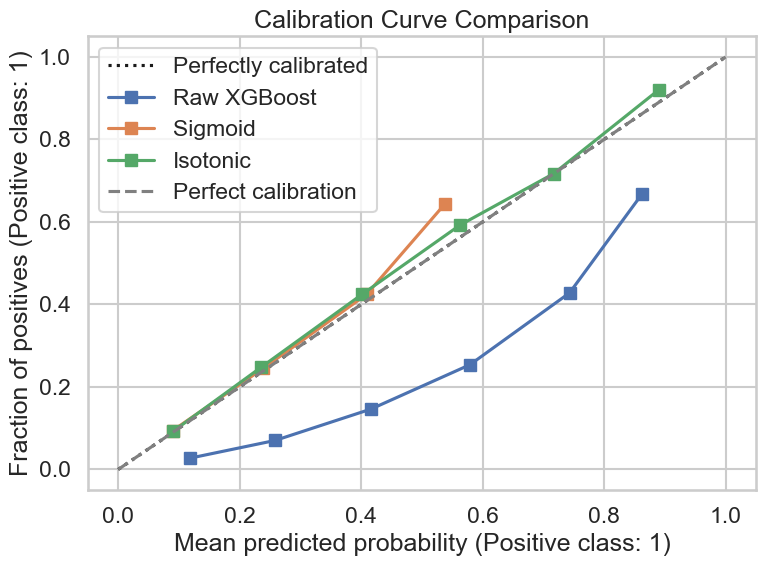

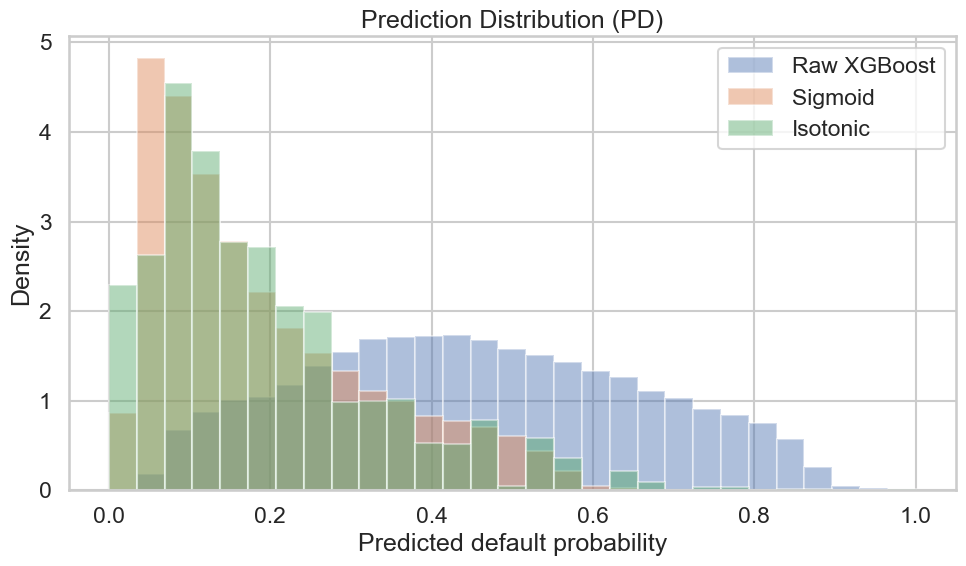

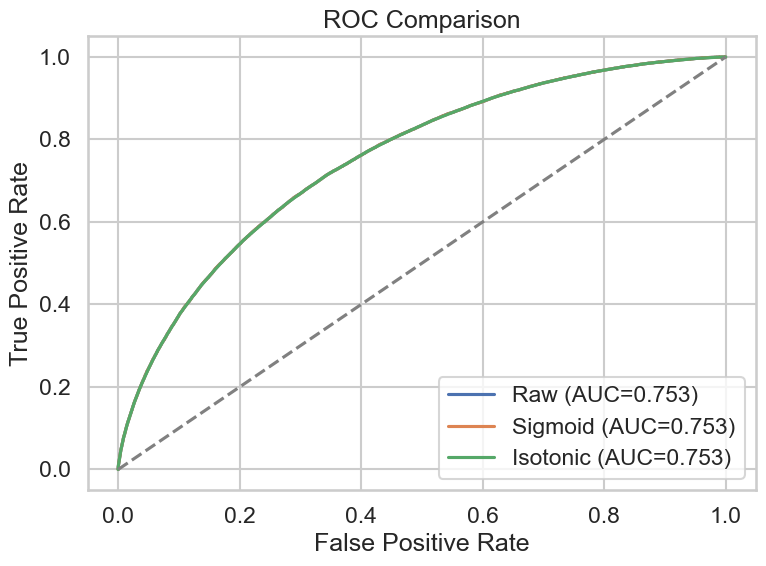

In [38]:
def expected_calibration_error(y_true, y_prob, n_bins=6):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(y_prob, bins[1:-1], right=True)

    ece = 0.0
    for b in range(n_bins):
        mask = bin_ids == b
        if not np.any(mask):
            continue
        bin_acc = y_true[mask].mean()
        bin_conf = y_prob[mask].mean()
        ece += (mask.mean()) * abs(bin_acc - bin_conf)
    return float(ece)

proba_raw = xgb_pipeline.predict_proba(X_test)[:, 1]
proba_sigmoid = cal_sigmoid.predict_proba(X_test)[:, 1]
proba_isotonic = cal_isotonic.predict_proba(X_test)[:, 1]

def metric_row(name, y_true, y_prob):
    return {
        "model": name,
        "roc_auc": roc_auc_score(y_true, y_prob),
        "brier": brier_score_loss(y_true, y_prob),
        "ece": expected_calibration_error(y_true, y_prob, n_bins=6),
        "avg_precision": average_precision_score(y_true, y_prob),
    }

summary_df = pd.DataFrame([
    metric_row("Raw XGBoost", y_test, proba_raw),
    metric_row("Sigmoid Calibrated", y_test, proba_sigmoid),
    metric_row("Isotonic Calibrated", y_test, proba_isotonic),
]).set_index("model")

print("Test-set metric summary:")
print(summary_df.round(4))

best_method = summary_df.sort_values(["ece", "brier", "roc_auc"], ascending=[True, True, False]).index[0]
print(f"\nBest calibration method by ECE/Brier tie-break: {best_method}")

# Calibration curves (n_bins between 5 and 8 as requested).
fig, ax = plt.subplots(figsize=(8, 6))
CalibrationDisplay.from_predictions(y_test, proba_raw, n_bins=6, name="Raw XGBoost", ax=ax)
CalibrationDisplay.from_predictions(y_test, proba_sigmoid, n_bins=6, name="Sigmoid", ax=ax)
CalibrationDisplay.from_predictions(y_test, proba_isotonic, n_bins=6, name="Isotonic", ax=ax)
ax.plot([0, 1], [0, 1], "--", color="gray", label="Perfect calibration")
ax.set_title("Calibration Curve Comparison")
ax.legend()
plt.tight_layout()
plt.show()

# Probability distribution histograms
fig, ax = plt.subplots(figsize=(10, 6))
bins = np.linspace(0, 1, 30)
ax.hist(proba_raw, bins=bins, alpha=0.45, label="Raw XGBoost", density=True)
ax.hist(proba_sigmoid, bins=bins, alpha=0.45, label="Sigmoid", density=True)
ax.hist(proba_isotonic, bins=bins, alpha=0.45, label="Isotonic", density=True)
ax.set_title("Prediction Distribution (PD)")
ax.set_xlabel("Predicted default probability")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()

# Optional discrimination visuals retained for model sanity checks.
fig, ax = plt.subplots(figsize=(8, 6))
fpr_raw, tpr_raw, _ = roc_curve(y_test, proba_raw)
fpr_sig, tpr_sig, _ = roc_curve(y_test, proba_sigmoid)
fpr_iso, tpr_iso, _ = roc_curve(y_test, proba_isotonic)
ax.plot(fpr_raw, tpr_raw, label=f"Raw (AUC={auc(fpr_raw, tpr_raw):.3f})")
ax.plot(fpr_sig, tpr_sig, label=f"Sigmoid (AUC={auc(fpr_sig, tpr_sig):.3f})")
ax.plot(fpr_iso, tpr_iso, label=f"Isotonic (AUC={auc(fpr_iso, tpr_iso):.3f})")
ax.plot([0, 1], [0, 1], "--", color="gray")
ax.set_title("ROC Comparison")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()
plt.tight_layout()
plt.show()

## 9) Interpretation
Interpret calibration behavior and suitability for risk decisioning.

In [39]:
observed_default = float(np.mean(y_test))

def confidence_bias(prob):
    delta = float(np.mean(prob) - observed_default)
    if delta > 0.01:
        return f"Overconfident (+{delta:.4f})"
    if delta < -0.01:
        return f"Underconfident ({delta:.4f})"
    return f"Well-centered ({delta:.4f})"

raw_brier = summary_df.loc["Raw XGBoost", "brier"]
sig_brier = summary_df.loc["Sigmoid Calibrated", "brier"]
iso_brier = summary_df.loc["Isotonic Calibrated", "brier"]

print("Interpretation notes:")
print(f"- Raw model confidence profile: {confidence_bias(proba_raw)}")
print(f"- Sigmoid confidence profile: {confidence_bias(proba_sigmoid)}")
print(f"- Isotonic confidence profile: {confidence_bias(proba_isotonic)}")
print(f"- Brier improvement (raw -> sigmoid): {raw_brier - sig_brier:+.4f}")
print(f"- Brier improvement (raw -> isotonic): {raw_brier - iso_brier:+.4f}")

isotonic_overfit_flag = (
    summary_df.loc["Isotonic Calibrated", "roc_auc"] < summary_df.loc["Raw XGBoost", "roc_auc"] - 0.01
    and summary_df.loc["Isotonic Calibrated", "ece"] > summary_df.loc["Raw XGBoost", "ece"]
 )
print(f"- Isotonic overfit signal: {'Yes' if isotonic_overfit_flag else 'No / limited evidence'}")

usable_probs = summary_df.loc[best_method, "ece"] < 0.03
print(f"- Probabilities usable for risk decisions: {'Yes' if usable_probs else 'Use caution; refine calibration'}")

print("\nFinal summary (requested):")
for model_name in summary_df.index:
    row = summary_df.loc[model_name]
    print(f"{model_name}: AUC={row['roc_auc']:.4f}, Brier={row['brier']:.4f}, ECE={row['ece']:.4f}")
print(f"Best calibration method: {best_method}")

Interpretation notes:
- Raw model confidence profile: Overconfident (+0.2535)
- Sigmoid confidence profile: Underconfident (-0.0100)
- Isotonic confidence profile: Well-centered (-0.0087)
- Brier improvement (raw -> sigmoid): +0.0694
- Brier improvement (raw -> isotonic): +0.0698
- Isotonic overfit signal: No / limited evidence
- Probabilities usable for risk decisions: Yes

Final summary (requested):
Raw XGBoost: AUC=0.7533, Brier=0.2071, ECE=0.2535
Sigmoid Calibrated: AUC=0.7533, Brier=0.1377, ECE=0.0100
Isotonic Calibrated: AUC=0.7532, Brier=0.1374, ECE=0.0087
Best calibration method: Isotonic Calibrated


## 10) Mock Candidates
Score five synthetic applicant profiles to illustrate predicted PD at origination.

In [29]:
mock_X = X_test.sample(n=5, random_state=2026).copy().reset_index(drop=True)
mock_X["candidate_id"] = [
    "CAND_001_Prime",
    "CAND_002_Stretch",
    "CAND_003_Balanced",
    "CAND_004_Risky",
    "CAND_005_Rebuilder",
]

def set_if_exists(df_in, col, values):
    if col in df_in.columns:
        df_in[col] = values

# Shape profiles to span risk spectrum while preserving schema.
set_if_exists(mock_X, "annual_inc", [180000, 52000, 95000, 38000, 65000])
set_if_exists(mock_X, "dti", [8.0, 28.0, 16.0, 35.0, 21.0])
set_if_exists(mock_X, "int_rate", [7.2, 17.0, 12.4, 24.5, 14.1])
set_if_exists(mock_X, "fico_range_high", [800, 710, 750, 660, 700])
set_if_exists(mock_X, "fico_range_low", [760, 670, 710, 620, 660])
set_if_exists(mock_X, "grade", ["A", "C", "B", "D", "C"] )
set_if_exists(mock_X, "sub_grade", ["A2", "C3", "B3", "D4", "C5"] )
set_if_exists(mock_X, "term", ["36 months", "60 months", "36 months", "60 months", "60 months"] )
set_if_exists(mock_X, "home_ownership", ["MORTGAGE", "RENT", "MORTGAGE", "RENT", "OWN"] )
set_if_exists(mock_X, "verification_status", ["Verified", "Not Verified", "Verified", "Source Verified", "Verified"] )
set_if_exists(mock_X, "purpose", ["debt_consolidation", "small_business", "credit_card", "major_purchase", "home_improvement"] )

mock_features = mock_X.drop(columns=["candidate_id"], errors="ignore")

pd_raw = xgb_pipeline.predict_proba(mock_features)[:, 1]
pd_sigmoid = cal_sigmoid.predict_proba(mock_features)[:, 1]
pd_isotonic = cal_isotonic.predict_proba(mock_features)[:, 1]

def risk_band(pd_value):
    if pd_value < 0.08:
        return "Low"
    if pd_value < 0.18:
        return "Moderate"
    if pd_value < 0.30:
        return "High"
    return "Very High"

mock_out = pd.DataFrame({
    "candidate_id": mock_X["candidate_id"],
    "pd_raw": pd_raw,
    "pd_sigmoid": pd_sigmoid,
    "pd_isotonic": pd_isotonic,
})
mock_out["risk_band"] = mock_out["pd_isotonic"].apply(risk_band)

for col in ["grade", "term", "annual_inc", "dti", "int_rate", "home_ownership", "purpose"]:
    if col in mock_X.columns:
        mock_out[col] = mock_X[col].values

ordered_cols = [
    "candidate_id", "grade", "term", "annual_inc", "dti", "int_rate",
    "home_ownership", "purpose", "pd_raw", "pd_sigmoid", "pd_isotonic", "risk_band",
]
ordered_cols = [c for c in ordered_cols if c in mock_out.columns]
mock_out = mock_out[ordered_cols].copy()

print("Mock candidate PD predictions:")
print(mock_out.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

Mock candidate PD predictions:
      candidate_id grade      term  annual_inc     dti  int_rate home_ownership            purpose  pd_raw  pd_sigmoid  pd_isotonic risk_band
    CAND_001_Prime     A 36 months      180000  8.0000    7.2000       MORTGAGE debt_consolidation  0.2273      0.0596       0.0651       Low
  CAND_002_Stretch     C 60 months       52000 28.0000   17.0000           RENT     small_business  0.8587      0.5432       0.6210 Very High
 CAND_003_Balanced     B 36 months       95000 16.0000   12.4000       MORTGAGE        credit_card  0.4956      0.1806       0.1839      High
    CAND_004_Risky     D 60 months       38000 35.0000   24.5000           RENT     major_purchase  0.8181      0.4961       0.5233 Very High
CAND_005_Rebuilder     C 60 months       65000 21.0000   14.1000            OWN   home_improvement  0.5565      0.2262       0.2246      High
